# 14. 임계값, Precision, Recall 이해하기

13장에서는 당뇨병 위험 예측 baseline 모델을 만들었습니다.

이번 장에서는 모델의 예측 확률을 0 또는 1로 바꾸는 기준인 `threshold`를 다룹니다.

핵심 질문:

```text
왜 0.5를 기준으로 0/1을 나눌까?
0.5가 항상 좋은 기준일까?
threshold를 바꾸면 precision과 recall은 어떻게 달라질까?
```

## 1. 라이브러리 불러오기

이번 장은 13장의 baseline 흐름을 다시 사용하고, 평가 지표를 더 자세히 봅니다.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# train_test_split은 데이터를 학습용과 검증용으로 나눕니다.
from sklearn.model_selection import train_test_split

# StandardScaler는 숫자 특성의 스케일을 맞춥니다.
from sklearn.preprocessing import StandardScaler

# precision_score, recall_score, f1_score는 각각 평가 지표를 계산합니다.
# confusion_matrix는 정답과 예측의 엇갈림을 표로 만듭니다.
# precision_recall_curve는 threshold 변화에 따른 precision/recall 곡선을 만듭니다.
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    precision_recall_curve,
    classification_report,
)

from keras.models import Sequential
from keras.layers import Input, Dense, Dropout

# 한글 폰트 설정 (맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호(-) 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

## 2. 데이터 읽기와 분리

13장과 같은 데이터 파일을 사용합니다.

In [2]:
DATA_PATH = Path(r"C:\work\dataset\diabetes_or_cardiovascular\diabetes_binary_5050split_health_indicators_BRFSS2015.csv")
TARGET = "Diabetes_binary"

# CSV 파일을 DataFrame으로 읽습니다.
df = pd.read_csv(DATA_PATH)

# 입력 X와 정답 y를 나눕니다.
X = df.drop(columns=[TARGET])
y = df[TARGET]

print("데이터 shape:", df.shape)
print("입력 shape:", X.shape)
print("정답 shape:", y.shape)
print("타깃 분포:")
print(y.value_counts().sort_index())

데이터 shape: (70692, 22)
입력 shape: (70692, 21)
정답 shape: (70692,)
타깃 분포:
Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64


In [3]:
# 데이터를 학습용과 검증용으로 나눕니다.
# stratify=y는 0/1 비율이 학습/검증에 비슷하게 유지되도록 합니다.
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 스케일러는 학습 데이터에만 fit합니다.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_val_scaled shape:", X_val_scaled.shape)

X_train_scaled shape: (56553, 21)
X_val_scaled shape: (14139, 21)


## 3. Baseline 모델 다시 만들기

이번 장의 목적은 모델 구조 개선이 아니라 threshold 이해입니다.

그래서 13장과 비슷한 작은 MLP를 사용합니다.

In [4]:
input_dim = X_train_scaled.shape[1]

model = Sequential([
    Input(shape=(input_dim,)),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,249 (4.88 KB)

 Trainable params: 1,249 (4.88 KB)

 Non-trainable params: 0 (0.00 B)

## 4. 모델 학습

`fit()`은 모델을 학습합니다.

이번 장에서는 threshold 분석이 목적이므로, 학습 코드는 baseline 수준으로 유지합니다.

In [5]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=10,
    batch_size=64,
    verbose=1
)

Epoch 1/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7278 - loss: 0.5394 - val_accuracy: 0.7495 - val_loss: 0.5079
Epoch 2/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7477 - loss: 0.5126 - val_accuracy: 0.7509 - val_loss: 0.5045
Epoch 3/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7507 - loss: 0.5095 - val_accuracy: 0.7500 - val_loss: 0.5035
Epoch 4/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7519 - loss: 0.5078 - val_accuracy: 0.7506 - val_loss: 0.5036
Epoch 5/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7522 - loss: 0.5069 - val_accuracy: 0.7523 - val_loss: 0.5033
Epoch 6/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7527 - loss: 0.5051 - val_accuracy: 0.7509 - val_loss: 0.5031
Epoch 7/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7528 - loss: 0.5050 - val_accuracy: 0.7530 - val_loss: 0.5020
Epoch 8/10
884/884 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7537 - loss: 0.5037 - val_accuracy: 0.

## 5. 예측 확률 만들기

sigmoid 출력은 0과 1 사이의 숫자입니다.

이 숫자를 바로 0/1로 보지 않고, 먼저 예측 확률로 저장합니다.

예측 확률 앞 10개:
[0.91099983 0.791232   0.41977805 0.02655181 0.75484353 0.8383248
 0.480685   0.79402745 0.46355835 0.5171536 ]


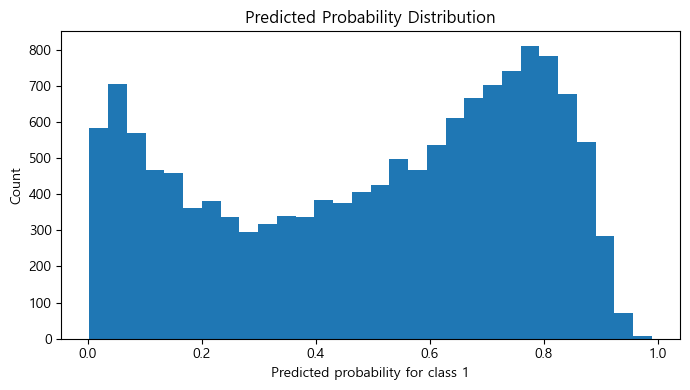

In [6]:
# predict()는 각 샘플에 대한 예측 확률을 반환합니다.
# ravel()은 (샘플 수, 1) 모양을 (샘플 수,) 모양으로 펴 줍니다.
y_val_prob = model.predict(X_val_scaled, verbose=0).ravel()

print("예측 확률 앞 10개:")
print(y_val_prob[:10])

plt.figure(figsize=(7, 4))
plt.hist(y_val_prob, bins=30)
plt.title("Predicted Probability Distribution")
plt.xlabel("Predicted probability for class 1")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 6. Threshold 하나로 평가하는 함수 만들기

threshold를 여러 개 비교하려면 같은 계산을 반복해야 합니다.

그래서 평가 함수를 하나 만듭니다.

In [7]:
def evaluate_threshold(y_true, y_prob, threshold):
    """주어진 threshold로 0/1 예측을 만들고 주요 평가 지표를 계산합니다."""
    
    # threshold 이상이면 1, 아니면 0으로 예측합니다.
    y_pred = (y_prob >= threshold).astype(int)
    
    # 각 평가 지표를 계산합니다.
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # confusion matrix에서 TN, FP, FN, TP를 꺼냅니다.
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    return {
        "threshold": threshold,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    }

## 7. Threshold 0.3, 0.5, 0.7 비교

threshold를 낮추면 더 많은 샘플을 1로 예측합니다.

threshold를 높이면 더 확신이 높은 경우만 1로 예측합니다.

In [8]:
thresholds = [0.3, 0.5, 0.7]

# 각 threshold에 대해 평가 결과를 계산합니다.
rows = [evaluate_threshold(y_val, y_val_prob, threshold) for threshold in thresholds]

# DataFrame으로 만들면 비교하기 쉽습니다.
threshold_df = pd.DataFrame(rows)
threshold_df

,threshold,accuracy,precision,recall,f1,TN,FP,FN,TP
0,0.3,0.722823,0.657942,0.928137,0.770025,3659,3411,508,6561
1,0.5,0.753519,0.730334,0.803791,0.765304,4972,2098,1387,5682
2,0.7,0.699413,0.813292,0.517612,0.632607,6230,840,3410,3659


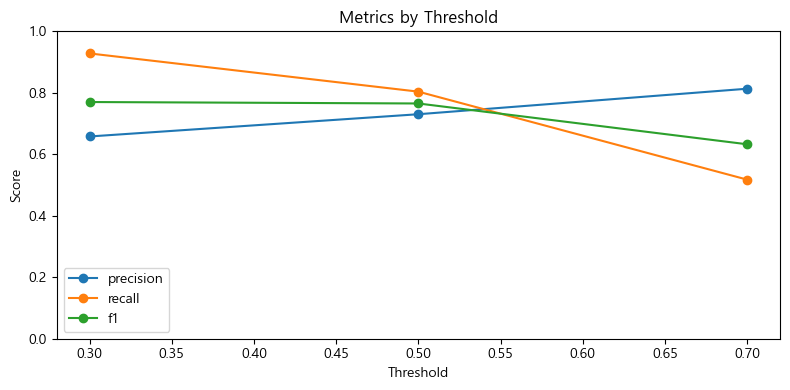

In [9]:
plt.figure(figsize=(8, 4))

plt.plot(threshold_df["threshold"], threshold_df["precision"], marker="o", label="precision")
plt.plot(threshold_df["threshold"], threshold_df["recall"], marker="o", label="recall")
plt.plot(threshold_df["threshold"], threshold_df["f1"], marker="o", label="f1")

plt.title("Metrics by Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend()
plt.tight_layout()
plt.show()

## 8. Confusion Matrix를 threshold별로 보기

숫자 지표만 보면 감이 약할 수 있습니다.

threshold별로 TN, FP, FN, TP가 어떻게 변하는지 봅니다.

건강 위험 예측에서는 특히 FN을 조심해서 봅니다.

In [10]:
for threshold in thresholds:
    y_pred = (y_val_prob >= threshold).astype(int)
    cm = confusion_matrix(y_val, y_pred)
    
    print(f"threshold = {threshold}")
    display(pd.DataFrame(
        cm,
        index=["actual 0", "actual 1"],
        columns=["pred 0", "pred 1"]
    ))

threshold = 0.3


,pred 0,pred 1
actual 0,3659,3411
actual 1,508,6561


threshold = 0.5


,pred 0,pred 1
actual 0,4972,2098
actual 1,1387,5682


threshold = 0.7


,pred 0,pred 1
actual 0,6230,840
actual 1,3410,3659


## 9. threshold 0.5 기준 classification report

가장 기본 기준인 0.5에서 classification report를 확인합니다.

하지만 이것이 항상 최종 선택이라는 뜻은 아닙니다.

In [11]:
y_val_pred_05 = (y_val_prob >= 0.5).astype(int)

print(classification_report(
    y_val,
    y_val_pred_05,
    target_names=["no diabetes", "diabetes"],
    zero_division=0
))

              precision    recall  f1-score   support

 no diabetes       0.78      0.70      0.74      7070
    diabetes       0.73      0.80      0.77      7069

    accuracy                           0.75     14139
   macro avg       0.76      0.75      0.75     14139
weighted avg       0.76      0.75      0.75     14139



## 10. Precision-Recall Curve

Precision-Recall Curve는 threshold를 아주 여러 값으로 바꿨을 때 precision과 recall이 어떻게 움직이는지 보여줍니다.

건강 위험 예측처럼 1 클래스를 잘 찾는 것이 중요한 문제에서 자주 확인합니다.

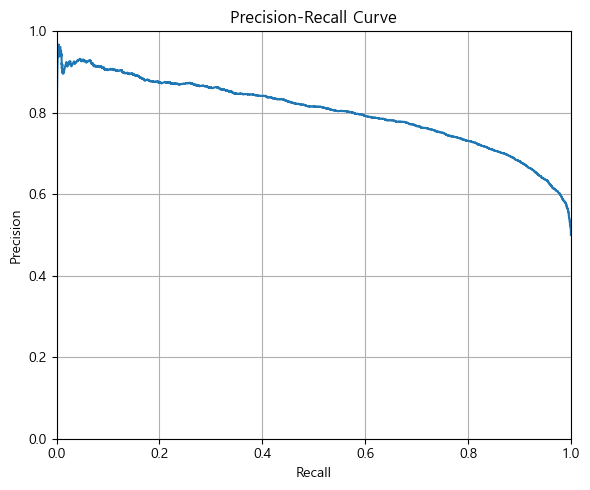

In [12]:
# precision_recall_curve()는 여러 threshold에 대한 precision과 recall 값을 계산합니다.
precisions, recalls, pr_thresholds = precision_recall_curve(y_val, y_val_prob)

plt.figure(figsize=(6, 5))
plt.plot(recalls, precisions)
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.grid(True)
plt.tight_layout()
plt.show()

## 11. 원하는 recall에 가까운 threshold 찾기

건강 위험 예측에서는 “recall을 최소한 어느 정도 이상으로 유지하고 싶다”는 목표를 세울 수 있습니다.

예를 들어 recall을 0.80 이상으로 유지하고 싶다면, 그 조건을 만족하는 threshold 후보를 찾아볼 수 있습니다.

In [13]:
target_recall = 0.80

candidate_rows = []

# pr_thresholds는 precisions/recalls보다 길이가 1 작습니다.
# 그래서 마지막 precision/recall 값은 제외하고 함께 묶습니다.
for precision, recall, threshold in zip(precisions[:-1], recalls[:-1], pr_thresholds):
    if recall >= target_recall:
        candidate_rows.append({
            "threshold": threshold,
            "precision": precision,
            "recall": recall,
        })

candidate_df = pd.DataFrame(candidate_rows)

# precision이 높은 후보를 위쪽에 보이도록 정렬합니다.
candidate_df = candidate_df.sort_values("precision", ascending=False)

candidate_df.head(10)

,threshold,precision,recall
6316,0.503881,0.731127,0.800113
6314,0.503692,0.731067,0.800255
6315,0.503746,0.731033,0.800113
6308,0.503421,0.731018,0.800820
6309,0.503454,0.730983,0.800679
6313,0.503686,0.730973,0.800255
6306,0.503221,0.730958,0.800962
6310,0.503480,0.730948,0.800538
6307,0.503384,0.730923,0.800820
6311,0.503486,0.730913,0.800396


## 12. 해석 문장 만들기

모델 평가 결과는 숫자로 끝내지 말고 문장으로 바꿔야 합니다.

아래 템플릿을 프로젝트 보고서에 맞게 고치면 됩니다.

In [14]:
print("해석 템플릿")
print("- threshold를 낮추면 1로 예측하는 샘플이 많아져 recall이 올라갈 수 있다.")
print("- threshold를 높이면 더 확신 있는 경우만 1로 예측하므로 precision이 올라갈 수 있다.")
print("- 건강 위험 예측에서는 실제 위험군을 놓치는 FN을 줄이는 것이 중요할 수 있다.")
print("- 따라서 accuracy만 보지 않고 precision, recall, f1-score를 함께 비교했다.")
print("- 최종 threshold는 프로젝트 목적과 오탐/미탐 비용을 고려해 선택해야 한다.")

해석 템플릿
- threshold를 낮추면 1로 예측하는 샘플이 많아져 recall이 올라갈 수 있다.
- threshold를 높이면 더 확신 있는 경우만 1로 예측하므로 precision이 올라갈 수 있다.
- 건강 위험 예측에서는 실제 위험군을 놓치는 FN을 줄이는 것이 중요할 수 있다.
- 따라서 accuracy만 보지 않고 precision, recall, f1-score를 함께 비교했다.
- 최종 threshold는 프로젝트 목적과 오탐/미탐 비용을 고려해 선택해야 한다.


## 13. 이번 장 정리

이번 장에서 배운 핵심은 다음과 같습니다.

```text
1. sigmoid 출력은 0~1 사이의 예측 점수다.
2. threshold는 예측 점수를 0/1로 바꾸는 기준이다.
3. threshold를 낮추면 recall이 올라가고 precision이 내려갈 수 있다.
4. threshold를 높이면 precision이 올라가고 recall이 내려갈 수 있다.
5. 건강 위험 예측에서는 FN을 줄이는 것이 중요할 수 있다.
```

## 과제

1. threshold 0.3, 0.5, 0.7 중 어떤 기준이 가장 좋아 보이는지 고르고 이유를 적어보세요.
2. FN과 FP 중 이 프로젝트에서 더 조심해야 할 것을 고르고 이유를 적어보세요.
3. recall을 높이면 생길 수 있는 단점을 설명해보세요.
4. 포트폴리오에 넣을 평가 해석 문장을 3문장으로 작성해보세요.